### **1. Introduction**
This notebook is to clip raw dataset only to the Western Province of Sri Lanka. The following things are done in this stage.

* Load administrative boundaries (GADM data).
* Perform a spatial join to filter pixels that fall within the Western Province polygon.
* Conduct initial Exploratory Data Analysis (EDA) to understand the statistical distribution of soil properties.

### **2. Setup**
Imported geopandas for spatial operations and shapely for geometric point creation.

In [63]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
from shapely.geometry import Point

sns.set_style("whitegrid")

In [64]:
# Load the raw pixels generated in notebook 01
df = pd.read_csv("../data/processed/soil_pixels_raw.csv")
print("Loaded pixels:", len(df))
df.head()

Loaded pixels: 60847


,lon,lat,bd_0-5cm,bd_15-30cm,bd_30-60cm,bd_5-15cm,bd_60-100cm,cec_0-5cm,cec_15-30cm,cec_30-60cm,...,vmc15_0-5cm,vmc15_15-30cm,vmc15_30-60cm,vmc15_5-15cm,vmc15_60-100cm,vmc33_0-5cm,vmc33_15-30cm,vmc33_30-60cm,vmc33_5-15cm,vmc33_60-100cm
0,80.200606,9.831007,1.474551,1.251214,1.247321,1.268088,1.267176,9.696836,10.050234,8.765096,...,0.091413,0.094432,0.086927,0.089380,0.113287,0.139779,0.141806,0.140917,0.136302,0.164341
1,80.210034,9.831007,1.477457,1.254274,1.248992,1.271305,1.267237,9.696094,10.049469,8.764836,...,0.090660,0.093527,0.086824,0.088607,0.113083,0.138718,0.140517,0.140769,0.135216,0.164066
2,80.219462,9.831007,1.480309,1.257274,1.250630,1.274452,1.267298,9.695372,10.048725,8.764590,...,0.089930,0.092652,0.086723,0.087860,0.112884,0.137684,0.139267,0.140626,0.134159,0.163800
3,80.040334,9.821579,1.448169,1.197490,1.218059,1.210042,1.266133,9.706892,10.061332,8.765575,...,0.106922,0.113572,0.088722,0.105516,0.117233,0.161814,0.169483,0.143784,0.159180,0.169806
4,80.144039,9.821579,1.456341,1.232489,1.237070,1.248343,1.266806,9.701566,10.055047,8.766954,...,0.095993,0.100113,0.087610,0.094113,0.114533,0.146450,0.150088,0.141942,0.143163,0.166092


### **3. Loading Geographic Boundaries**
The administrative boundaries of Sri Lanka was imported and ensured that the Coordinate Reference System (CRS) is set to EPSG:4326 (WGS84), which matches Longitude and Latitude data.

In [65]:
districts = gpd.read_file("../data/boundaries/gadm41_LKA_1.json")
districts = districts.to_crs("EPSG:4326")

districts[["NAME_1"]].drop_duplicates()

,NAME_1
0,Ampara
1,Anuradhapura
2,Badulla
3,Batticaloa
4,Colombo
5,Galle
6,Gampaha
7,Hambantota
8,Jaffna
9,Kalutara


### **4. Polygon Dissolving**
The three districts that make up the Western Province were selected and dissolved their internal borders to create one single continuous polygon representing the entire province.

In [66]:
# Define the target administrative districts
western_names = ["Colombo", "Gampaha", "Kalutara"]

# Filter the geodataframe for western province districts
western_districts = districts[districts["NAME_1"].isin(western_names)]

# Merge the three districts into one provincial boundary
western_polygon = western_districts.dissolve()

### **5. Point in Polygon Analysis**
The tabular DataFrame was converted into a GeoDataFrame. This uses a spatial join to keep only the points that physically sit inside the western province boundary.

In [67]:
# Create geometric Point objects from longitude and latitude columns
geometry = [Point(xy) for xy in zip(df.lon, df.lat)]

# Convert standard dataframe to a geodataframe
pixels_gdf = gpd.GeoDataFrame(df, geometry=geometry, crs="EPSG:4326")

# Perform spatial join to keep pixels within the western province polygon
western_pixels = gpd.sjoin(
    pixels_gdf,
    western_polygon,
    how="inner",
    predicate="within"
)

# Drop administrative columns used for joining to keep only soil data
df_wp = western_pixels.drop(columns=["geometry", "index_right", "GID_1", "NAME_1", "GID_0", "COUNTRY", "VARNAME_1", "NL_NAME_1", "TYPE_1", "ENGTYPE_1", "CC_1", "HASC_1", "ISO_1"]).reset_index(drop=True)

print("Western Province pixels:", len(df_wp))
df_wp.head()

Western Province pixels: 3422


,lon,lat,bd_0-5cm,bd_15-30cm,bd_30-60cm,bd_5-15cm,bd_60-100cm,cec_0-5cm,cec_15-30cm,cec_30-60cm,...,vmc15_0-5cm,vmc15_15-30cm,vmc15_30-60cm,vmc15_5-15cm,vmc15_60-100cm,vmc33_0-5cm,vmc33_15-30cm,vmc33_30-60cm,vmc33_5-15cm,vmc33_60-100cm
0,80.125184,7.323213,1.557927,1.442331,1.439978,1.415508,1.345131,15.267301,16.852371,15.398573,...,0.136998,0.124837,0.130485,0.133131,0.115818,0.195194,0.176813,0.185719,0.189695,0.158228
1,80.134612,7.323213,1.558571,1.440546,1.438355,1.412790,1.345062,15.265265,16.851543,15.398051,...,0.138358,0.125894,0.130853,0.134477,0.116135,0.197316,0.178222,0.186291,0.191714,0.158815
2,80.002622,7.313786,1.543519,1.542667,1.551212,1.527530,1.348263,15.189331,16.596306,14.792064,...,0.112024,0.105075,0.111875,0.109097,0.105837,0.158121,0.150447,0.156935,0.155038,0.137779
3,80.012050,7.313786,1.543147,1.543052,1.551626,1.527253,1.348302,15.187772,16.595743,14.791530,...,0.113405,0.106234,0.112188,0.110480,0.106229,0.159969,0.151812,0.157299,0.156828,0.138326
4,80.021478,7.313786,1.542923,1.543448,1.552039,1.527009,1.348340,15.186189,16.595175,14.790990,...,0.114780,0.107385,0.112495,0.111856,0.106619,0.161818,0.153168,0.157660,0.158620,0.138870


### **6. Exporting the Refined Dataset**
Clipped dataset was saved to use for further analysis.

In [68]:
output_path = "../data/processed/soil_pixels_western.csv"
df_wp.to_csv(output_path, index=False)

print("Saved:", output_path)

Saved: ../data/processed/soil_pixels_western.csv


### **7. Statistical Profiling**
The mean, standard deviation, and range of soil properties were examined. This helps to identify if values are within realistic agronomic ranges.

In [69]:
df_wp.describe().T

,count,mean,std,min,25%,50%,75%,max
lon,3422.0,80.066672,0.114186,79.823494,79.983767,80.068617,80.144039,80.379734
lat,3422.0,6.834095,0.267123,6.333295,6.597273,6.832968,7.068663,7.323213
bd_0-5cm,3422.0,1.199866,0.159718,0.881094,1.082684,1.179130,1.299784,1.558571
bd_15-30cm,3422.0,1.350280,0.083035,1.233191,1.289022,1.324751,1.382893,1.543448
bd_30-60cm,3422.0,1.382651,0.069076,1.285070,1.334027,1.359051,1.409916,1.552039
bd_5-15cm,3422.0,1.283805,0.099869,1.144020,1.208835,1.261994,1.326283,1.527530
bd_60-100cm,3422.0,1.346927,0.110631,1.030793,1.259291,1.381019,1.409231,1.556693
cec_0-5cm,3422.0,14.933392,4.122962,8.014023,10.125175,16.370080,18.288928,21.867239
cec_15-30cm,3422.0,14.527231,4.823737,6.922479,8.382486,17.126350,18.471093,21.328356
cec_30-60cm,3422.0,13.632701,3.970161,6.982351,8.610965,15.522872,17.006080,19.756760


### **8. Feature Histograms**
Visualizing the distribution of features helps to understand if the soil properties are normally distributed or if they have skewness.

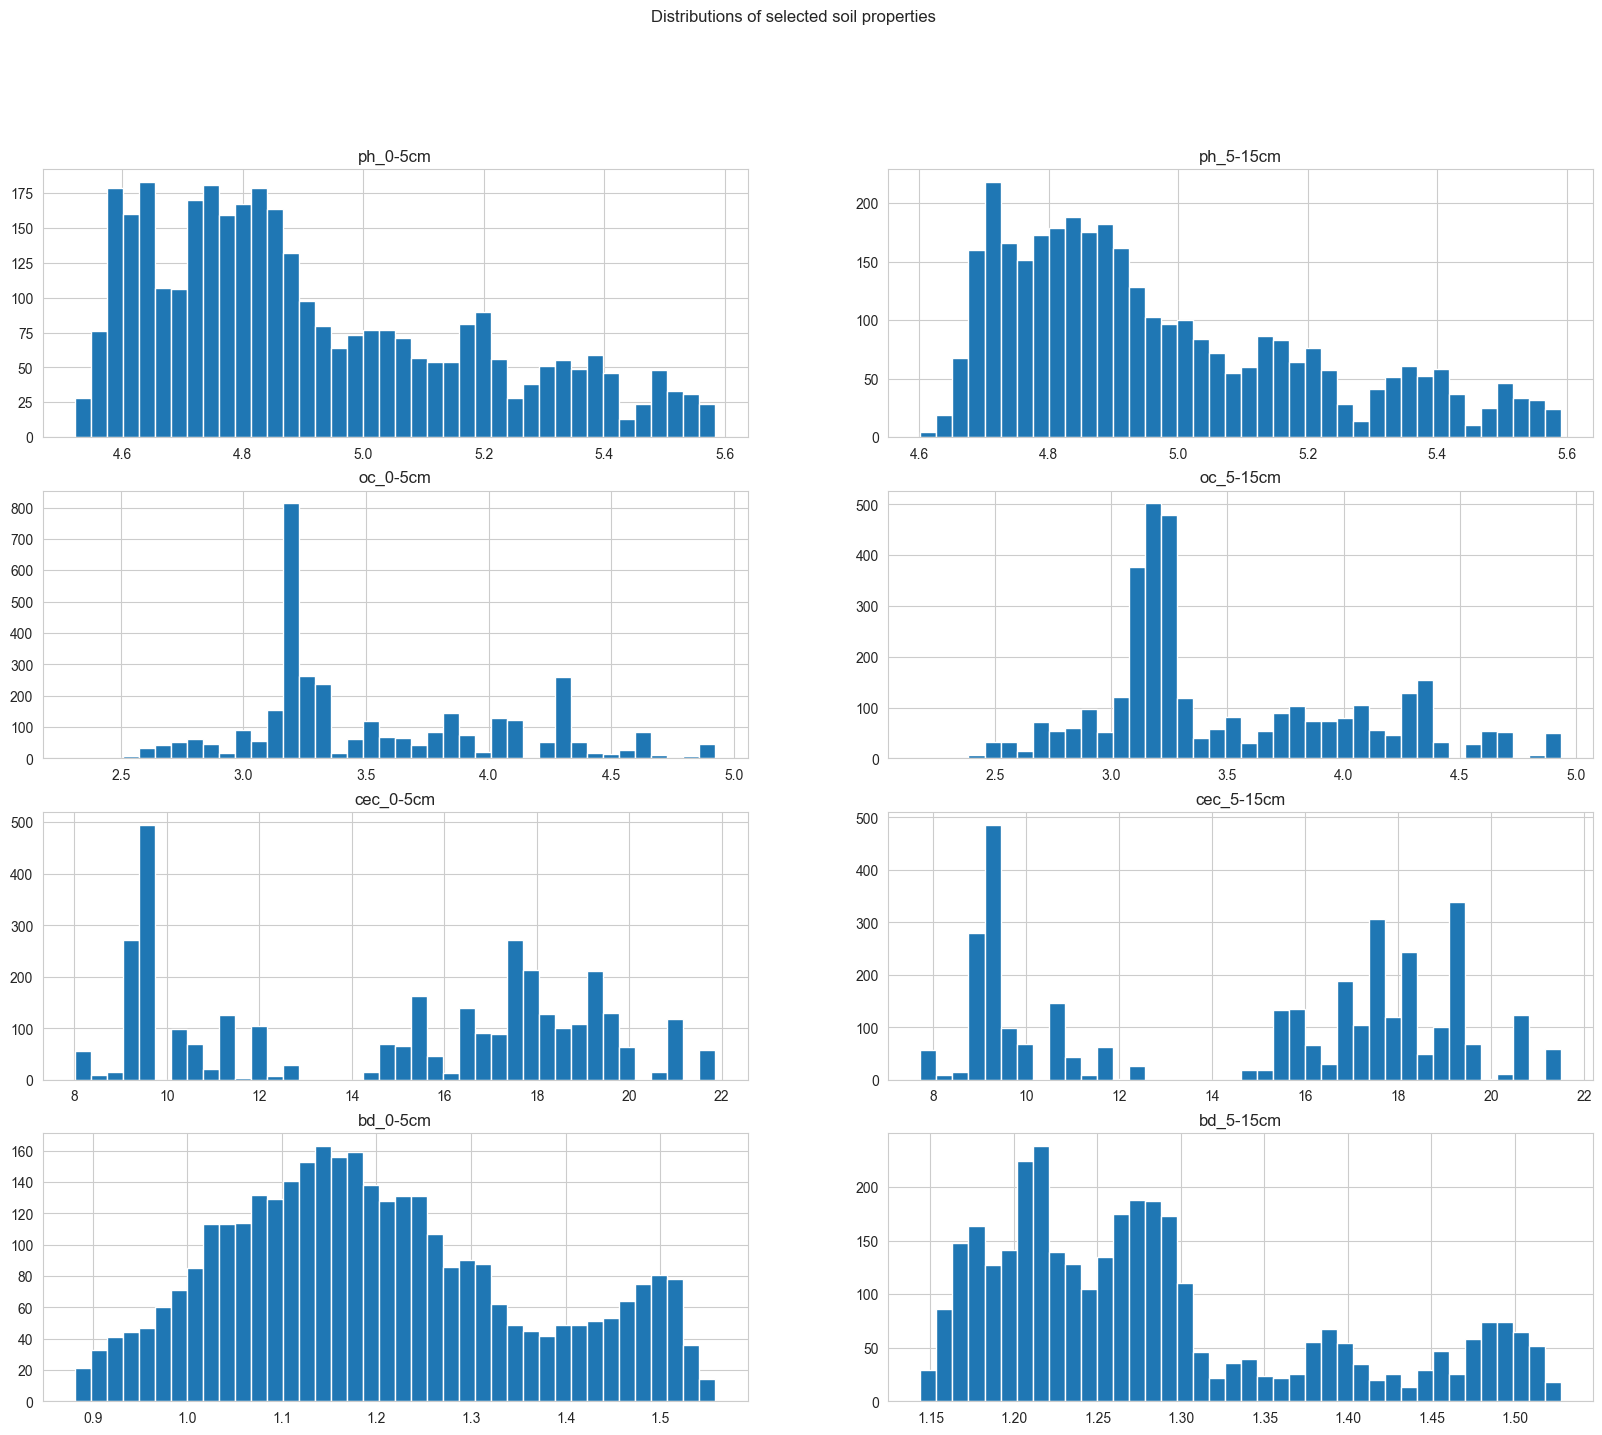

In [70]:
properties = ["ph", "oc", "cec", "bd"]
depths = ["0-5cm", "5-15cm"]

ordered_patterns = [f"{p}_{d}" for p in properties for d in depths]

prop_cols = [
    c for pattern in ordered_patterns
    for c in df_wp.columns
    if pattern in c
]

fig, ax = plt.subplots(4, 2, figsize=(20, 16))

k = 0
for i in range(4):
    for j in range(2):
        ax[i, j].hist(df_wp[prop_cols[k]], bins=40)
        ax[i, j].set_title(prop_cols[k])
        k += 1

plt.suptitle("Distributions of selected soil properties")
plt.show()


### **9. Map of Filtered Data**
The final plot shows the shape of data. It perfectly resembles the Western Province without any noise from neighboring provinces or the ocean.

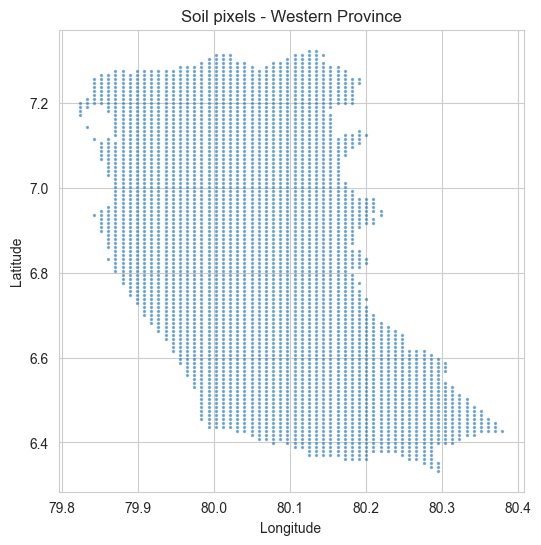

In [71]:
plt.figure(figsize=(6, 6))
plt.scatter(df_wp.lon, df_wp.lat, s=2, alpha=0.5)
plt.title("Soil pixels - Western Province")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()